In [1]:
import numpy as np
from astropy.io import ascii as asc
import matplotlib.pyplot as plt
from fleck import Star
import fleck
import astropy.units as u
import healpy as hp
import matplotlib.patches as mpatches

In [2]:
## -- load LCO data
l = np.load('./data/lcogt/LCO_sinistro_data.npz')
t_jd_g = l['t_jd_g']
y_g = l['y_g']
yerr_g = l['yerr_g']

t_jd_r = l['t_jd_r']
y_r = l['y_r']
yerr_r = l['yerr_r']

t_g = t_jd_g - t_jd_r[0] # offset by start of r-band obs.
t_r = t_jd_r - t_jd_r[0] 

In [3]:
Nvals = np.arange(1, 11, 1, dtype=int)
Nmax = Nvals[-1]
fits = np.zeros((len(Nvals), 3 * Nmax))

for i, N in enumerate(Nvals):
    if not (5 <= N <= 6): continue
    path = 'data/lcogt/lcofit_newv2_simul_s%d_nolim_paramfits_v1.h5.npz' % (N)
    l = np.load(path)
    pars = l['fits']
    fits[i, 0:N]              = pars[0:N]
    fits[i, Nmax:Nmax+N]      = pars[N:2*N]
    fits[i, 2*Nmax:2*Nmax+N]  = pars[2*N:3*N]

In [4]:
LDCs = [0.581, 0.137]
Prot = 2.97
inc_stellar = 90.0*u.deg

tc_c = 60924.269172581
tc_b = 60929.002944444
tc_d = 60928.860150000

Jv1_start = 60924.08916926491
Jv1_end = 60924.45689687428
Jv2_start = 60928.680153672634
Jv2_end = 60929.13808086981

rot_diff = (tc_d-tc_c)/Prot
londiff = (360.0*rot_diff) % (360.)

v3_spotradii = np.array([[0.05766],[0.07870],[0.11685],[0.26535],[0.04773],[0.180],[0.252],[0.219],[0.041],[0.223],[0.175],[0.139],[0.134],[0.045]])
v3_spotlats = np.array([[-32.25],[-30.49],[-27.36],[-18.90],[-32.284],[-27.0],[-4.31],[-38.88],[-29.93],[-37.62],[-17.59],[-32.52],[-20.53],[-30.16]])
v3_spotlons = np.array([[-46.91],[-37.71],[-12.01],[2.21],[22.49],[46.15],[-18.03+londiff],[-3.83+londiff],[-42.14+londiff],[-25.19+londiff],[1.8+londiff],[18.61+londiff],[30.18+londiff],[-59.73+londiff]])
v3_gcontrast = 1. - 0.663
v3_rcontrast = 1. - 0.589


phases_r = (t_r % Prot) / Prot
phases_g = (t_g % Prot) / Prot

star_v3g = fleck.Star(spot_contrast=v3_gcontrast, n_phases=len(t_g), u_ld=LDCs, rotation_period=Prot)
star_v3r = fleck.Star(spot_contrast=v3_rcontrast, n_phases=len(t_r), u_ld=LDCs, rotation_period=Prot)

fixed_radii = np.copy(v3_spotradii)
fixed_lats = np.copy(v3_spotlats)
fixed_lons = np.copy(v3_spotlons)

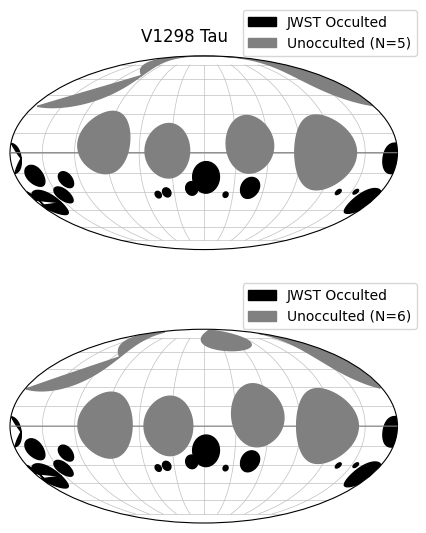

In [5]:
N_top = 5
N_bot = 6
i_top = np.where(Nvals == N_top)[0][0]
i_bot = np.where(Nvals == N_bot)[0][0]

def draw_spot(ax, lon_deg, lat_deg, rad_rad, color, zorder=2):
    n = 100
    angles = np.linspace(0, 2*np.pi, n)
    r = rad_rad
    lon0 = np.radians(lon_deg)
    lat0 = np.radians(lat_deg)
    lons = lon0 + r * np.cos(angles) / np.cos(lat0)
    lats = lat0 + r * np.sin(angles)
    lats = np.clip(lats, -np.pi/2, np.pi/2)
    lons = (lons + np.pi) % (2 * np.pi) - np.pi
    breaks = np.where(np.abs(np.diff(lons)) > np.pi)[0] + 1
    segments = np.split(np.column_stack([lons, lats]), breaks)
    for seg in segments:
        if len(seg) > 1 and np.ptp(seg[:, 0]) < np.pi:  # skip wrap-around slivers
            ax.fill(seg[:, 0], seg[:, 1], color=color, zorder=zorder)

fig_map = plt.figure(figsize=(5, 6))
gs_map = fig_map.add_gridspec(2, 1, hspace=0.1, top=0.92, bottom=0.05)
ax_map_top = fig_map.add_subplot(gs_map[0, 0], projection='mollweide')
ax_map_bot = fig_map.add_subplot(gs_map[1, 0], projection='mollweide')

for ax, i, N in zip([ax_map_top, ax_map_bot], [i_top, i_bot], [N_top, N_bot]):
    # Fixed spots
    for j in range(len(v3_spotradii)):
        lon = v3_spotlons[j][0]
        lat = v3_spotlats[j][0]
        rad = v3_spotradii[j][0] * 0.8
        draw_spot(ax, lon, lat, rad, color='black')
    # Fitted spots
    lons = fits[i, 0:N]
    lats = fits[i, Nmax:Nmax+N]
    rads = fits[i, 2*Nmax:2*Nmax+N]
    for lon, lat, rad in zip(lons, lats, rads):
        draw_spot(ax, lon, lat, rad, color='gray')

    ax.set_facecolor('white')
    ax.grid(True, color='silver', linestyle='-', linewidth=0.5)
    ax.set_facecolor('white')
    ax.grid(True, color='silver', linestyle='-', linewidth=0.5)
    ax.plot(np.linspace(-np.pi, np.pi, 500), np.zeros(500), color='gray', linewidth=0.8, zorder=3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    fixed_patch  = mpatches.Patch(color='black', label='JWST Occulted')
    fitted_patch = mpatches.Patch(color='gray',  label='Unocculted (N=%d)' % N)
    ax.legend(handles=[fixed_patch, fitted_patch], loc=(.6, 1), fontsize=10, frameon=True)

ax_map_top.set_title('V1298 Tau', pad=10, x=0.45)

plt.savefig('./figures/Figure8_v1298tau_maps.pdf', dpi=600, bbox_inches='tight')
plt.show()